# WASP2026 draft: plot-type accuracy by figure category

A single heatmap panel. It replaces the three-panel "counting and types"
figure this notebook used to build from the `jcdl_followup` run; that code has
been removed, and is in git history if it is ever wanted back.

* **y-axis** -- the low-tier models in the run directory below
* **x-axis** -- what the figure actually is: contour, sky image from a gaussian
  mixture ("fake"), or sky image from a real survey cutout
* **cell value** -- accuracy of the *plot type* question, the same binary
  comparison the original panel uses (exact string match after lowercasing and
  stripping spaces), averaged over the figures in that category

The x-axis is the reason this needs its own parsing rather than the pipeline
above. The plot-type question's ground truth is only `contour` or
`image of the sky` -- it cannot tell a synthetic sky from a real one. The
three-way category comes from the figure's own data (`plot0.distribution` in
the qa json), not from any answer.

These cells are self-contained -- they do not use `parse_lmm_output_utils` or
`results_plotting_utils`, which are not part of this repo.


In [1]:
# ======================== CONFIG ========================
# One row of the figure per run: (row label, directory of per-model pickles).
# All three cover the SAME 150 figures, so the rows differ only by how the page
# was treated before it was sent.
runs = [
    ('original',      '~/Dropbox/WASP2026/LMM_outputs_n150/'),
    ('archive',       '~/Dropbox/WASP2026/LMM_outputs_n150_archive/'),
    ('archive-light', '~/Dropbox/WASP2026/LMM_outputs_n150_archive_light/'),
]

# The full-strength 'archive' aging may not make the paper -- this drops that
# row without touching anything else.
show_archive = True

# The released VQA jsons -- needed for each figure's true category.
qa_jsons_dir = '~/Dropbox/WASP2026/VQA/qa_jsons/'

fig_out_dir = '~/Dropbox/WASP2026/paper_figures/'
fig_name    = 'plot_type_by_category.pdf'

# model subdirectory -> display name, in the order they should appear top to
# bottom.  Same low tier as low_dirs_to_use in the original figure.
model_names = {
    'chatgpt_api':  'GPT',
    'gemini':       'Gemini',
    'claude_haiku': 'Claude',
}

# The plot-type question is asked twice: once offering [contour, image of the
# sky] as a list, once open-ended.  The original figure scores the list variant
# (question_types[0] has 'use list': True).  The open-ended one scores ~0 for
# every model -- they answer things like "Astronomical survey image", which
# never matches the ground-truth string -- so it measures phrasing, not vision.
use_list_variant = True

# x-axis order and labels
category_order  = ['contour', 'sky-gmm', 'sky-real']
category_labels = {'contour':  'contour',
                   'sky-gmm':  'sky image\n(synth data)',
                   'sky-real': 'sky image\n(real data)'}

show_counts_in_xlabel = True    # append (n=...) to each column label

# Rows are packed close together and only the BOTTOM one keeps its x-axis
# labels, since all rows share the same three categories.
row_gap      = 0.06     # vertical space between rows, as a fraction of row height
row_height_in = 2.2     # height of one row
fig_width_in  = 7.6


In [2]:
import os, json, glob, pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

run_dir      = os.path.expanduser(run_dir)
qa_jsons_dir = os.path.expanduser(qa_jsons_dir)
fig_out_dir  = os.path.expanduser(fig_out_dir)
os.makedirs(fig_out_dir, exist_ok=True)


def json_objects(s):
    """Every top-level JSON object in `s`, in order, using the real decoder."""
    if not isinstance(s, str):
        return []
    dec, out, i = json.JSONDecoder(), [], 0
    while True:
        i = s.find('{', i)
        if i < 0:
            break
        try:
            obj, end = dec.raw_decode(s, i)
        except ValueError:
            i += 1
            continue
        if isinstance(obj, dict):
            out.append(obj)
        i = end
    return out


def recovered_answer(entry):
    """
    The model's answer to one question.

    `entry['Response']` cannot be used directly: the models reply with two
    fenced json blocks (answer, then explanation) and parse_qa keeps only the
    last, so Response is usually the explanation alone.  Merging every object
    found in `raw answer` recovers the answer; the first non-explanation key is
    it, whatever the model chose to call it ("plot_types", "plot type", ...).
    """
    merged = {}
    for o in json_objects(entry.get('raw answer')):
        merged.update(o)
    resp = entry.get('Response')
    if isinstance(resp, dict):
        for k, v in resp.items():
            merged.setdefault(k, v)
    for k, v in merged.items():
        if k.lower().strip() != 'explanation':
            return v
    return None


def normalise(x):
    """Match the original panel's comparison: lowercase, spaces stripped."""
    return str(x).lower().replace(' ', '').replace('_', '').strip()


_cat_cache = {}

def figure_category(vqa_id):
    """contour / sky-gmm / sky-real, from the figure's own data."""
    if vqa_id in _cat_cache:
        return _cat_cache[vqa_id]
    with open(os.path.join(qa_jsons_dir, vqa_id + '_qa.json')) as f:
        d = json.loads(json.load(f))
    types, dists = set(), set()
    for k, v in d.items():
        if k.startswith('plot'):
            types.add(v.get('type'))
            dists.add(v.get('distribution'))
    if types == {'contour'}:
        c = 'contour'
    elif types == {'image of the sky'}:
        c = 'sky-gmm' if dists == {'gmm'} else 'sky-real'
    else:
        c = 'other'
    _cat_cache[vqa_id] = c
    return c


In [3]:
# ======================== PARSE ========================
active_runs = [(lab, d) for lab, d in runs if show_archive or lab != 'archive']

rows = []
for run_label, run_dir in active_runs:
  run_dir = os.path.expanduser(run_dir)
  for mdir, mname in model_names.items():
    pkls = sorted(glob.glob(os.path.join(run_dir, mdir, '*_qa.pickle')))
    if not pkls:
        print('[WARN] no pickles in', os.path.join(run_dir, mdir))
        continue
    for fp in pkls:
        vqa_id = os.path.basename(fp).removesuffix('_qa.pickle')
        with open(fp, 'rb') as f:
            payload = pickle.load(f)
        qa_list = payload[0] if isinstance(payload, (list, tuple)) else payload
        model_id = payload[1] if isinstance(payload, (list, tuple)) and len(payload) > 1 else mdir

        for e in qa_list:
            q = (e.get('question') or '').lower()
            if 'plot type' not in q:
                continue
            # the two variants differ only by the multiple-choice list in context
            offers_list = 'please choose' in (e.get('context') or '').lower()
            if offers_list != use_list_variant:
                continue

            truth = list(e['A'].values())[0]
            if isinstance(truth, list):
                truth = truth[0] if truth else ''
            answer = recovered_answer(e)
            if isinstance(answer, list):
                answer = answer[0] if answer else ''

            rows.append({'model': mname, 'model_id': model_id, 'vqa_id': vqa_id,
                         'category': figure_category(vqa_id),
                         'truth': truth, 'answer': answer,
                         'correct': int(normalise(truth) == normalise(answer))})

dfcat = pd.DataFrame(rows)
print('parsed %d plot-type answers from %d model(s), %d figures'
      % (len(dfcat), dfcat['model'].nunique(), dfcat['vqa_id'].nunique()))
print()
print('figures per category:')
print(dfcat.groupby('category')['vqa_id'].nunique().to_string())
dfcat.head()


parsed 450 plot-type answers from 3 model(s), 150 figures

figures per category:
category
contour     50
sky-gmm     50
sky-real    50


,model,model_id,vqa_id,category,truth,answer,correct
0,GPT,gpt-5.4-nano-2026-03-17,vqa_000013,sky-gmm,image of the sky,contour,0
1,GPT,gpt-5.4-nano-2026-03-17,vqa_000015,sky-gmm,image of the sky,contour,0
2,GPT,gpt-5.4-nano-2026-03-17,vqa_000016,contour,contour,contour,1
3,GPT,gpt-5.4-nano-2026-03-17,vqa_000017,contour,contour,image of the sky,0
4,GPT,gpt-5.4-nano-2026-03-17,vqa_000018,contour,contour,contour,1


In [5]:
dfcat[dfcat['model']=='Claude']

,model,model_id,vqa_id,category,truth,answer,correct
300,Claude,claude-haiku-4-5,vqa_000013,sky-gmm,image of the sky,image of the sky,1
301,Claude,claude-haiku-4-5,vqa_000015,sky-gmm,image of the sky,image of the sky,1
302,Claude,claude-haiku-4-5,vqa_000016,contour,contour,image of the sky,0
303,Claude,claude-haiku-4-5,vqa_000017,contour,contour,image of the sky,0
304,Claude,claude-haiku-4-5,vqa_000018,contour,contour,image of the sky,0
...,...,...,...,...,...,...,...
445,Claude,claude-haiku-4-5,vqa_000164,sky-gmm,image of the sky,image of the sky,1
446,Claude,claude-haiku-4-5,vqa_000166,sky-gmm,image of the sky,image of the sky,1
447,Claude,claude-haiku-4-5,vqa_000167,sky-gmm,image of the sky,image of the sky,1
448,Claude,claude-haiku-4-5,vqa_000169,sky-gmm,image of the sky,image of the sky,1


wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/plot_type_by_category.pdf


category,contour,sky-gmm,sky-real
model,,,
GPT,50.0,60.0,74.0
Gemini,80.0,100.0,98.0
Claude,20.0,100.0,100.0


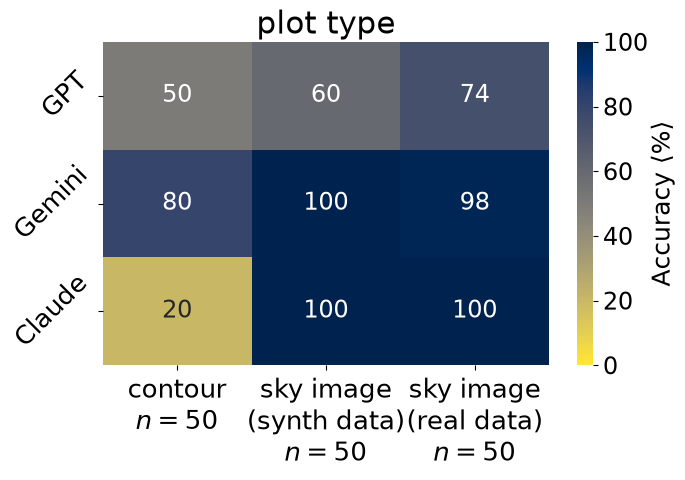

In [ ]:
# ======================== PLOT ========================
fontsize          = 22
tick_fontsize     = 19
barfontsize       = 18
cbar_tick_fontsize = 17
annot_fontsize    = 17
annot_fmt         = '.0f'
cmap              = 'cividis_r'
barpad            = 2
acctag            = r'Accuracy $\mathrm{\langle \% \rangle}$'

pivot = (dfcat.pivot_table(index='model', columns='category',
                           values='correct', aggfunc='mean') * 100)
# fixed row/column order rather than whatever pandas sorts to
pivot = pivot.reindex([v for v in model_names.values() if v in pivot.index])
pivot = pivot.reindex(columns=[c for c in category_order if c in pivot.columns])

counts = dfcat.groupby('category')['vqa_id'].nunique()
xlabels = []
for c in pivot.columns:
    lab = category_labels.get(c, c)
    if show_counts_in_xlabel:
        lab += '\n$n=%d$' % counts.get(c, 0)
    xlabels.append(lab)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.heatmap(pivot, annot=True, fmt=annot_fmt, cmap=cmap, vmin=0, vmax=100,
            ax=ax, annot_kws={'size': annot_fontsize})

ax.set_title('plot type', fontsize=fontsize)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(xlabels, fontsize=tick_fontsize)
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right', va='center')
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

cbar = ax.collections[0].colorbar
cbar.set_label(acctag, fontsize=barfontsize, labelpad=barpad)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))
cbar.ax.tick_params(labelsize=cbar_tick_fontsize)

fig.savefig(os.path.join(fig_out_dir, fig_name), bbox_inches='tight')
print('wrote', os.path.join(fig_out_dir, fig_name))
pivot.round(1)
